# 📊 Week 7: Statistical Business Analysis
This notebook covers Descriptive Statistics, Data Distributions, Hypothesis Testing, Correlation, Confidence Intervals, and Regression Analysis.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sales = pd.read_csv("D:\Week7_Project\sales_data.csv")
churn = pd.read_csv("D:\Week7_Project\customer_churn.csv")
print("✅ Data loaded successfully.")

✅ Data loaded successfully.


### 1. Descriptive Statistics

In [2]:
desc_stats = sales[['Quantity', 'Price', 'Total_Sales']].describe()
mode_sales = sales[['Quantity', 'Price', 'Total_Sales']].mode().iloc[0]
print("Descriptive Statistics:\n", desc_stats)
print("\nMode:\n", mode_sales)

Descriptive Statistics:
          Quantity         Price    Total_Sales
count  100.000000    100.000000     100.000000
mean     4.780000  25808.510000  123650.480000
std      2.588163  13917.630242  100161.085275
min      1.000000   1308.000000    6540.000000
25%      2.750000  14965.250000   39517.500000
50%      5.000000  24192.000000   97955.500000
75%      7.000000  38682.250000  175792.500000
max      9.000000  49930.000000  373932.000000

Mode:
 Quantity          4.0
Price          1308.0
Total_Sales    6540.0
Name: 0, dtype: float64


### 2. Data Distribution & Testing

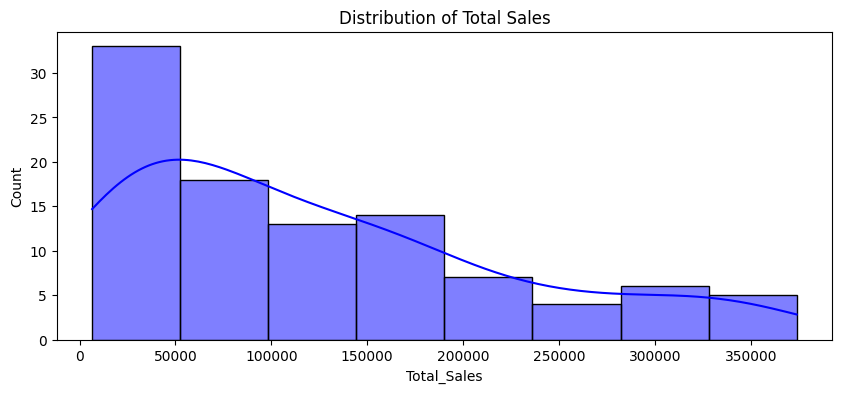

Shapiro-Wilk Test for Normality - p-value: 0.00000
Data is NOT normally distributed (Reject H0)


In [3]:
plt.figure(figsize=(10, 4))
sns.histplot(sales['Total_Sales'], kde=True, color='blue')
plt.title('Distribution of Total Sales')
plt.show()

stat, p_norm = stats.shapiro(sales['Total_Sales'])
print(f"Shapiro-Wilk Test for Normality - p-value: {p_norm:.5f}")
if p_norm < 0.05:
    print("Data is NOT normally distributed (Reject H0)")
else:
    print("Data IS normally distributed (Fail to reject H0)")

### 3. Correlation Analysis

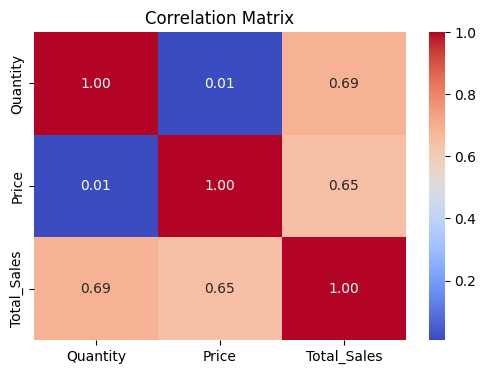

In [4]:
corr_matrix = sales[['Quantity', 'Price', 'Total_Sales']].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

### 4. Hypothesis Testing

In [5]:
# Test 1: T-test (Churn vs Monthly Charges)
churn_yes = churn[churn['Churn'] == 1]['MonthlyCharges']
churn_no = churn[churn['Churn'] == 0]['MonthlyCharges']
t_stat1, p_val1 = stats.ttest_ind(churn_yes, churn_no)
print(f"T-test (Churn vs MonthlyCharges) p-value: {p_val1:.4f}")

# Test 2: ANOVA (Region vs Total Sales)
regions = [sales[sales['Region'] == r]['Total_Sales'] for r in sales['Region'].unique()]
f_stat, p_val2 = stats.f_oneway(*regions)
print(f"ANOVA (Region vs Total_Sales) p-value: {p_val2:.4f}")

# Test 3: T-test (SeniorCitizen vs MonthlyCharges)
senior_yes = churn[churn['SeniorCitizen'] == 1]['MonthlyCharges']
senior_no = churn[churn['SeniorCitizen'] == 0]['MonthlyCharges']
t_stat3, p_val3 = stats.ttest_ind(senior_yes, senior_no)
print(f"T-test (SeniorCitizen vs MonthlyCharges) p-value: {p_val3:.4f}")

T-test (Churn vs MonthlyCharges) p-value: 0.0163
ANOVA (Region vs Total_Sales) p-value: 0.0972
T-test (SeniorCitizen vs MonthlyCharges) p-value: 0.0181


### 5. Confidence Intervals

In [6]:
def confidence_interval(data, confidence=0.95):
    n = len(data)
    m = np.mean(data)
    se = stats.sem(data)
    h = se * stats.t.ppf((1 + confidence) / 2., n-1)
    return m, m-h, m+h, h

mean_sales, ci_low, ci_high, margin = confidence_interval(sales['Total_Sales'])
print(f"Average Total Sales: ₹{mean_sales:,.2f} ± ₹{margin:,.2f} (95% CI: ₹{ci_low:,.2f} to ₹{ci_high:,.2f})")

Average Total Sales: ₹123,650.48 ± ₹19,874.13 (95% CI: ₹103,776.35 to ₹143,524.61)


### 6. Regression Analysis

In [7]:
X = sales['Quantity']
Y = sales['Total_Sales']
X = sm.add_constant(X)
model = sm.OLS(Y, X).fit()
print("Linear Regression (Quantity -> Total_Sales):")
print(f"R-squared: {model.rsquared:.4f}")
print(f"P-value: {model.pvalues['Quantity']:.4e}")

Linear Regression (Quantity -> Total_Sales):
R-squared: 0.4735
P-value: 2.5805e-15
